In [1]:
# ================================================================
# CELL 1 — IMPORTS
# ================================================================

import os, math, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import albumentations as A
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, f1_score, balanced_accuracy_score,
    precision_recall_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='colorblind')
tf.random.set_seed(42)
np.random.seed(42)

print('✅ Import selesai')
print(f'   TF  : {tf.__version__}')
print(f'   GPU : {tf.config.list_physical_devices("GPU")}')

2026-06-02 08:26:37.616935: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780388797.800469      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780388797.852991      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780388798.281286      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780388798.281324      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780388798.281327      23 computation_placer.cc:177] computation placer alr

✅ Import selesai
   TF  : 2.19.0
   GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Path dataset
BASE_INPUT   = '/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia'
FILE_INDIA   = os.path.join(BASE_INPUT, 'India', 'India.xlsx')
FILE_ITALY   = os.path.join(BASE_INPUT, 'Italy', 'Italy.xlsx')
FOLDER_INDIA = os.path.join(BASE_INPUT, 'India')
FOLDER_ITALY = os.path.join(BASE_INPUT, 'Italy')
OUTPUT_DIR   = '/kaggle/working/model_anemia'
SYNTH_DIR    = '/kaggle/working/synthetic_images'

In [3]:
# Label threshold HGB
HGB_FEMALE = 12.0
HGB_MALE   = 13.0
HGB_OTHER  = 12.0

# Keyword nama file gambar
IMAGE_KEYWORD = 'palpebral'

# Hyperparameter training
RANDOM_SEED     = 42
IMG_SIZE        = 224
BATCH_SIZE      = 16
TOTAL_EPOCHS    = 80
LR_INITIAL      = 1e-3
LR_FINETUNE     = 5e-5
LR_MIN          = 1e-6
UNFREEZE_EPOCH  = 50    
WARMUP_EPOCHS   = 5
N_TTA = 8

# Split ratio
TRAIN_RATIO = 0.50
VAL_RATIO   = 0.30
TEST_RATIO  = 0.20

In [4]:
# Data generation
SYNTH_MULTIPLIER = 3   # N× augmentasi per gambar minoritas
SMOTE_MAX        = 200  # batas maksimal gambar SMOTE

# Flags
USE_ONLINE_OVERSAMPLE = True   # 50/50 per batch
USE_OFFLINE_SYNTH     = True   # generate gambar ke disk

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SYNTH_DIR,  exist_ok=True)
print(f'Output    : {OUTPUT_DIR}')
print(f'Synthetic : {SYNTH_DIR}')

Output    : /kaggle/working/model_anemia
Synthetic : /kaggle/working/synthetic_images


In [5]:
# ================================================================
# CELL 3 — SCAN FOLDER
# ================================================================

def scan_folder_by_number(country_folder, keyword=IMAGE_KEYWORD):
    """
    Scan subfolder bernomor (1/, 2/, 3/, ...) di dalam country_folder.
    Cari file gambar yang mengandung keyword, return dict {number: path}.
    """
    number_to_path  = {}
    missing_keyword = []

    if not os.path.exists(country_folder):
        print(f'  ⚠️  Folder tidak ada: {country_folder}')
        return number_to_path

    for item in sorted(os.listdir(country_folder)):
        subfolder = os.path.join(country_folder, item)
        if not os.path.isdir(subfolder):
            continue
        try:
            number = int(item)
        except ValueError:
            continue

        found = None
        all_imgs = []
        for fname in sorted(os.listdir(subfolder)):
            ext = os.path.splitext(fname)[1].lower()
            if ext not in ('.jpg', '.jpeg', '.png', '.bmp', '.tiff'):
                continue
            all_imgs.append(fname)
            if keyword == '' or keyword.lower() in fname.lower():
                found = os.path.join(subfolder, fname)
                break

        if found:
            number_to_path[number] = found
        else:
            missing_keyword.append((number, all_imgs))

    print(f'  Ditemukan : {len(number_to_path)} gambar valid')
    if missing_keyword:
        print(f'  ⚠️  {len(missing_keyword)} subfolder tanpa keyword "{keyword}"')
        for num, imgs in missing_keyword[:3]:
            print(f'     Number={num}: {imgs[:3]}')
        if len(missing_keyword) > 3:
            print(f'     ... dan {len(missing_keyword)-3} lainnya')
    return number_to_path


print('Scan India...')
map_india = scan_folder_by_number(FOLDER_INDIA)
print('Scan Italy...')
map_italy = scan_folder_by_number(FOLDER_ITALY)

# Fallback: ambil semua gambar jika keyword tidak ketemu
if not map_india:
    print('⚠️  Fallback India: tanpa keyword...')
    map_india = scan_folder_by_number(FOLDER_INDIA, keyword='')
if not map_italy:
    print('⚠️  Fallback Italy: tanpa keyword...')
    map_italy = scan_folder_by_number(FOLDER_ITALY, keyword='')

print(f'\nTotal peta: India={len(map_india)}, Italy={len(map_italy)}')


Scan India...
  Ditemukan : 95 gambar valid
Scan Italy...
  Ditemukan : 122 gambar valid
  ⚠️  1 subfolder tanpa keyword "palpebral"
     Number=95: ['T_64_20190612_092742.jpg', 'T_64_20190612_092742_forniceal.png', 'T_64_20190612_092742_forniceal_palplebral.png']

Total peta: India=95, Italy=122


In [6]:
# ================================================================
# CELL 4 — LOAD EXCEL + LABELING OTOMATIS
# ================================================================

def load_and_label_excel(file_path, number_to_path_map, country_name):
    """
    Baca Excel, bersihkan HGB, buat label Anemia/Non-Anemia,
    cocokkan dengan path gambar dari scan folder.
    """
    df   = pd.read_excel(file_path)
    junk = [c for c in df.columns
            if 'unnamed' in c.lower() or c.lower() in ('note', 'notes')]
    df   = df.drop(columns=junk, errors='ignore')
    print(f'\n[{country_name}] Kolom: {list(df.columns)}')

    col_map = {c.strip().lower(): c.strip() for c in df.columns}

    # Cari kolom Number
    num_col = next(
        (col_map[c] for c in ('number','no','no.','id','sample','num')
         if c in col_map), None)
    if not num_col:
        raise ValueError(f"Kolom Number tidak ditemukan di {country_name}")

    # Cari kolom HGB
    hgb_col = next(
        (col_map[c] for c in ('hgb','hemoglobin','hb','haemoglobin')
         if c in col_map), None)
    if not hgb_col:
        raise ValueError(f"Kolom HGB tidak ditemukan di {country_name}")

    # Bersihkan HGB
    df['Hgb_clean'] = pd.to_numeric(
        df[hgb_col].astype(str)
                   .str.replace(',', '.', regex=False).str.strip(),
        errors='coerce'
    )

    # Kolom Gender (opsional)
    gender_col = next(
        (col_map[c] for c in ('gender','sex','jenis kelamin')
         if c in col_map), None)
    df['Gender_clean'] = (df[gender_col].astype(str).str.strip()
                          if gender_col else 'Unknown')

    # Drop baris tanpa HGB / Number
    df = df.dropna(subset=['Hgb_clean']).copy()
    df[num_col] = pd.to_numeric(df[num_col], errors='coerce')
    df = df.dropna(subset=[num_col]).copy()
    df[num_col] = df[num_col].astype(int)

    # Label otomatis berdasarkan HGB + gender
    def assign_label(row):
        hgb = row['Hgb_clean']
        g   = row['Gender_clean'].upper()
        if g in ('F','FEMALE','PEREMPUAN','P','W','WANITA'):
            return 'Anemia' if hgb < HGB_FEMALE else 'Non-Anemia'
        elif g in ('M','MALE','LAKI','LAKI-LAKI','L','PRIA','MAN'):
            return 'Anemia' if hgb < HGB_MALE else 'Non-Anemia'
        else:
            return 'Anemia' if hgb < HGB_OTHER else 'Non-Anemia'

    df['label']     = df.apply(assign_label, axis=1)
    df['y']         = (df['label'] == 'Anemia').astype(int)
    df['full_path'] = df[num_col].map(number_to_path_map)

    matched = df['full_path'].notna().sum()
    print(f'  Sampel total   : {len(df)}')
    print(f'  Gambar matched : {matched}')
    print(f'  Anemia         : {(df["y"]==1).sum()} ({(df["y"]==1).mean()*100:.1f}%)')
    print(f'  Non-Anemia     : {(df["y"]==0).sum()} ({(df["y"]==0).mean()*100:.1f}%)')
    print(f'  HGB range      : {df["Hgb_clean"].min():.1f} – {df["Hgb_clean"].max():.1f}')

    return df[['full_path','Hgb_clean','Gender_clean','label','y']].copy()


dfs = []
if os.path.exists(FILE_INDIA) and map_india:
    dfs.append(load_and_label_excel(FILE_INDIA, map_india, 'India'))
if os.path.exists(FILE_ITALY) and map_italy:
    dfs.append(load_and_label_excel(FILE_ITALY, map_italy, 'Italy'))
if not dfs:
    raise RuntimeError("Tidak ada data yang berhasil dimuat.")

df_all   = pd.concat(dfs, ignore_index=True)
df_valid = df_all.dropna(subset=['full_path']).reset_index(drop=True)

# Label encode sebelum generate
le = LabelEncoder()
df_valid['y_enc'] = le.fit_transform(df_valid['label'])
ANEM_IDX = int(np.where(le.classes_ == 'Anemia')[0][0])

print(f'\nTotal valid  : {len(df_valid)}')
print(f'Distribusi   : {df_valid["label"].value_counts().to_dict()}')
print(f'Kelas        : {list(le.classes_)} | Anemia idx: {ANEM_IDX}')


[India] Kolom: ['Number', 'Hgb', 'Gender', 'Age']
  Sampel total   : 95
  Gambar matched : 95
  Anemia         : 68 (71.6%)
  Non-Anemia     : 27 (28.4%)
  HGB range      : 7.6 – 17.1

[Italy] Kolom: ['Number', 'Hgb', 'Gender', 'Age']
  Sampel total   : 122
  Gambar matched : 121
  Anemia         : 23 (18.9%)
  Non-Anemia     : 99 (81.1%)
  HGB range      : 7.0 – 17.4

Total valid  : 216
Distribusi   : {'Non-Anemia': 125, 'Anemia': 91}
Kelas        : ['Anemia', 'Non-Anemia'] | Anemia idx: 0


In [7]:
# CELL 5 — DEFINISI AUGMENTASI
# ================================================================

aug_train = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.08,
                       rotate_limit=10,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.20,
                                contrast_limit=0.20, p=0.7),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=20,
                         val_shift_limit=10, p=0.6),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.4),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.25)
])

aug_synth = A.Compose([  
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.10, scale_limit=0.15,
                       rotate_limit=20,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.8),
    A.RandomBrightnessContrast(brightness_limit=0.30,
                                contrast_limit=0.30, p=0.8),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30,
                         val_shift_limit=15, p=0.7),
    A.CLAHE(clip_limit=3.0, tile_grid_size=(8,8), p=0.5),
    A.GaussNoise(var_limit=(10.0, 40.0), p=0.4),
    A.ElasticTransform(alpha=1, sigma=10, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.3),
    A.CoarseDropout(max_holes=4, max_height=20, max_width=20,
                    min_holes=1, fill_value='random', p=0.3),
    A.Resize(IMG_SIZE, IMG_SIZE),
])

aug_tta = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.05,
                       rotate_limit=5,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.10,
                                contrast_limit=0.10, p=0.5),
    A.Resize(IMG_SIZE, IMG_SIZE),
])

aug_eval = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE,
                  border_mode=cv2.BORDER_CONSTANT, value=0)
])

print('✅ Augmentasi terdefinisi')

✅ Augmentasi terdefinisi


In [8]:

# ================================================================
# CELL 6 — FUNGSI DATA GENERATION
# ================================================================

def generate_synthetic_images(df_src, synth_dir, multiplier, label_enc):
    """
    Augmentasi gambar kelas minoritas sebanyak multiplier×,
    simpan ke synth_dir. Return DataFrame berisi path baru.
    """
    counts   = df_src['y_enc'].value_counts()
    min_cls  = counts.idxmin()
    min_name = label_enc.classes_[min_cls]
    maj_name = label_enc.classes_[counts.idxmax()]

    print(f'\n[Offline Generation]')
    print(f'  Mayoritas : {maj_name} ({counts.max()})')
    print(f'  Minoritas : {min_name} ({counts.min()})')
    print(f'  Multiplier: {multiplier}×')

    df_min      = df_src[df_src['y_enc'] == min_cls].reset_index(drop=True)
    rows        = []
    n_generated = 0

    for _, row in df_min.iterrows():
        img_bgr = cv2.imread(row['full_path'])
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        for _ in range(multiplier):
            out   = aug_synth(image=img_rgb)['image']
            fname = f'synth_{min_name}_{n_generated:05d}.jpg'
            path  = os.path.join(synth_dir, fname)
            cv2.imwrite(path, cv2.cvtColor(out, cv2.COLOR_RGB2BGR),
                        [cv2.IMWRITE_JPEG_QUALITY, 95])
            rows.append({
                'full_path'    : path,
                'Hgb_clean'   : row['Hgb_clean'],
                'Gender_clean': row['Gender_clean'],
                'label'        : row['label'],
                'y'            : row['y'],
                'y_enc'        : row['y_enc'],
            })
            n_generated += 1

    print(f'  ✅ {n_generated} gambar sintetis dibuat')
    return pd.DataFrame(rows)


def image_smote(df_src, synth_dir, n_samples, label_enc):
    """
    Buat n_samples gambar baru dengan interpolasi dua gambar
    dari kelas minoritas (image-space SMOTE).
    """
    counts   = df_src['y_enc'].value_counts()
    min_cls  = counts.idxmin()
    min_name = label_enc.classes_[min_cls]
    df_min   = df_src[df_src['y_enc'] == min_cls].reset_index(drop=True)

    if len(df_min) < 2:
        print('  ⚠️  Kelas minoritas < 2 sampel, SMOTE dilewati.')
        return pd.DataFrame()

    print(f'\n[Image SMOTE] {n_samples} gambar → kelas {min_name}')
    rows        = []
    n_generated = 0

    for i in range(n_samples):
        a, b = np.random.choice(len(df_min), 2, replace=False)
        row_a, row_b = df_min.iloc[a], df_min.iloc[b]
        img_a = cv2.imread(row_a['full_path'])
        img_b = cv2.imread(row_b['full_path'])
        if img_a is None or img_b is None:
            continue
        img_a = cv2.resize(img_a, (IMG_SIZE, IMG_SIZE))
        img_b = cv2.resize(img_b, (IMG_SIZE, IMG_SIZE))
        lam   = np.random.uniform(0.3, 0.7)
        mixed = (lam * img_a.astype(np.float32) +
                 (1 - lam) * img_b.astype(np.float32)).astype(np.uint8)
        fname = f'smote_{min_name}_{n_generated:05d}.jpg'
        path  = os.path.join(synth_dir, fname)
        cv2.imwrite(path, mixed, [cv2.IMWRITE_JPEG_QUALITY, 95])
        rows.append({
            'full_path'    : path,
            'Hgb_clean'   : row_a['Hgb_clean'],
            'Gender_clean': row_a['Gender_clean'],
            'label'        : row_a['label'],
            'y'            : row_a['y'],
            'y_enc'        : row_a['y_enc'],
        })
        n_generated += 1

    print(f'  ✅ {n_generated} gambar SMOTE dibuat')
    return pd.DataFrame(rows)

In [9]:
# ================================================================
# CELL 7 — SPLIT DULU ➔ BARU GENERATE (ANTI-DATA LEAKAGE)
# ================================================================

print(f'\nData ASLI sebelum di-apa-apakan: {len(df_valid)}')
print(df_valid['label'].value_counts())

# 1. SPLIT STRATIFIED DI AWAL (Menggunakan data asli yang murni)
train_val, test_df = train_test_split(
    df_valid, test_size=TEST_RATIO,
    random_state=RANDOM_SEED, stratify=df_valid['y_enc'])

val_rel = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_df_raw, val_df = train_test_split(
    train_val, test_size=val_rel,
    random_state=RANDOM_SEED, stratify=train_val['y_enc'])

# 2. GENERATE SYNTHETIC & SMOTE *HANYA* UNTUK DATA TRAIN
if USE_OFFLINE_SYNTH:
    print("\n[INFO] Menjalankan Sintesis Data & SMOTE khusus untuk DATA TRAIN...")
    df_synth = generate_synthetic_images(train_df_raw, SYNTH_DIR, SYNTH_MULTIPLIER, le)

    gap = abs(int(train_df_raw['y_enc'].value_counts().max() -
                  train_df_raw['y_enc'].value_counts().min()))
    n_smote = min(gap, SMOTE_MAX)
    df_smote = image_smote(train_df_raw, SYNTH_DIR, n_smote, le) if n_smote > 0 else pd.DataFrame()

    parts = [p for p in [train_df_raw, df_synth, df_smote] if len(p) > 0]
    train_df = pd.concat(parts, ignore_index=True) \
                 .sample(frac=1, random_state=RANDOM_SEED) \
                 .reset_index(drop=True)
else:
    train_df = train_df_raw.copy()

# Reset index untuk data validasi dan test asli
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# 3. HITUNG CLASS WEIGHTS DARI DATA TRAIN YANG SUDAH DI-AUGMENTASI
n0 = (train_df['y_enc'] == 0).sum()
n1 = (train_df['y_enc'] == 1).sum()
CLASS_WEIGHTS = {0: len(train_df) / (2 * n0),
                 1: len(train_df) / (2 * n1)}

print(f'\n--- HASIL AKHIR SPLIT & AUGMENTASI ---')
print(f'Train (Plus Synth) : {len(train_df)} | Val (Murni) : {len(val_df)} | Test (Murni) : {len(test_df)}')
print(f'Train dist : {train_df["label"].value_counts().to_dict()}')
print(f'Val dist   : {val_df["label"].value_counts().to_dict()}')
print(f'Test dist  : {test_df["label"].value_counts().to_dict()}')
print(f'Class weights: {CLASS_WEIGHTS}')


Data ASLI sebelum di-apa-apakan: 216
label
Non-Anemia    125
Anemia         91
Name: count, dtype: int64

[INFO] Menjalankan Sintesis Data & SMOTE khusus untuk DATA TRAIN...

[Offline Generation]
  Mayoritas : Non-Anemia (62)
  Minoritas : Anemia (45)
  Multiplier: 3×


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


  ✅ 135 gambar sintetis dibuat

[Image SMOTE] 17 gambar → kelas Anemia


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


  ✅ 17 gambar SMOTE dibuat

--- HASIL AKHIR SPLIT & AUGMENTASI ---
Train (Plus Synth) : 259 | Val (Murni) : 65 | Test (Murni) : 44
Train dist : {'Anemia': 197, 'Non-Anemia': 62}
Val dist   : {'Non-Anemia': 38, 'Anemia': 27}
Test dist  : {'Non-Anemia': 25, 'Anemia': 19}
Class weights: {0: np.float64(0.6573604060913706), 1: np.float64(2.088709677419355)}


In [10]:

# ================================================================
# CELL 8 — DATA GENERATOR
# ================================================================

def load_image(path, aug_pipeline):
    """Baca gambar, augmentasi, preprocess untuk EfficientNet."""
    img = cv2.imread(path, cv2.IMREAD_IGNORE_ORIENTATION | cv2.IMREAD_COLOR)
    if img is None:
        return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = aug_pipeline(image=img)['image']
    return preprocess_input(img.astype(np.float32))


def mixup_batch(X, y, alpha=0.2):
    """MixUp: interpolasi dua sampel dalam satu batch."""
    bs  = len(X)
    lam = np.random.beta(alpha, alpha, bs)
    idx = np.random.permutation(bs)
    lx  = lam.reshape(bs, 1, 1, 1).astype(np.float32)
    ly  = lam.reshape(bs, 1).astype(np.float32)
    X_mix = lx * X + (1 - lx) * X[idx]
    y_mix = (ly * y.reshape(-1,1) + (1-ly) * y[idx].reshape(-1,1)).flatten()
    return X_mix, y_mix


class AnemiaGenerator(keras.utils.Sequence):
    """Generator standar — dipakai untuk val & test."""
    def __init__(self, df, aug_pipeline, batch_size, shuffle=False):
        self.df         = df.reset_index(drop=True)
        self.aug        = aug_pipeline
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.indices    = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        sel   = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        rows  = self.df.iloc[sel]
        X     = np.array([load_image(r['full_path'], self.aug)
                          for _, r in rows.iterrows()], dtype=np.float32)
        y     = rows['y_enc'].values.astype(np.float32)
        return X, y


class BalancedAnemiaGenerator(keras.utils.Sequence):
    def __init__(self, df, aug_pipeline, batch_size,
                 use_mixup=True, mixup_alpha=0.2):
        self.df          = df.reset_index(drop=True)
        self.aug         = aug_pipeline
        self.batch_size  = batch_size
        self.use_mixup   = use_mixup
        self.mixup_alpha = mixup_alpha
        self.half_bs     = batch_size // 2
        self.idx_cls     = {
            c: self.df[self.df['y_enc'] == c].index.tolist()
            for c in self.df['y_enc'].unique()
        }
        self._build_queues()

    def _build_queues(self):
        self.queues = {}
        total_steps = len(self)
        for cls, idxs in self.idx_cls.items():
            shuffled = idxs.copy()
            np.random.shuffle(shuffled)
            needed  = self.half_bs * total_steps
            reps    = math.ceil(needed / max(len(shuffled), 1))
            self.queues[cls] = (shuffled * reps)[:needed]

    def __len__(self):
        n_maj = max(len(v) for v in self.idx_cls.values())
        return math.ceil(n_maj / self.half_bs)

    def on_epoch_end(self):
        self._build_queues()

    def __getitem__(self, idx):
        s = idx * self.half_bs
        e = s + self.half_bs
        rows = pd.concat([
            self.df.iloc[self.queues[c][s:e]]
            for c in sorted(self.idx_cls)
        ]).sample(frac=1)

        X = np.array([load_image(r['full_path'], self.aug)
                      for _, r in rows.iterrows()], dtype=np.float32)
        y = rows['y_enc'].values.astype(np.float32)

        if self.use_mixup and len(X) > 1:
            X, y = mixup_batch(X, y, self.mixup_alpha)
        return X, y

In [11]:
class CustomF1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        # Menggunakan divide_no_nan aman dari eror pembagian dengan nol (0/0)
        return tf.math.divide_no_nan(2.0 * p * r, p + r)

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

In [12]:
def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                l2_reg=1e-4, spatial_drop=0.20, units=256):
    
    # 1. Load Backbone EfficientNetB0
    backbone = EfficientNetB0(
        weights = 'imagenet',
        include_top = False,
        input_shape=input_shape,
        pooling=None
    )
    # Set trainable True untuk persiapan fine-tuning tahap lanjut
    backbone.trainable = True

    # 2. Definisikan Alur Arsitektur
    inputs = keras.Input(shape=input_shape, name="input_layer")
    
    # training=False menjaga statistik BatchNormalization internal tetap stabil bawaan ImageNet
    x = backbone(inputs, training=False)
    
    x = layers.SpatialDropout2D(spatial_drop, name='spatial_dropout')(x)
    x = layers.GlobalAveragePooling2D(name='global_avg_pooling')(x)
    x = layers.LayerNormalization(name='feature_normalization')(x)
    
    # Dense Projection
    x = layers.Dense(
        units,
        kernel_regularizer = regularizers.l2(l2_reg),
        name = 'dense_projection'
    )(x)
    x = layers.BatchNormalization(name='batch_norm_projection')(x)
    x = layers.Activation('relu', name='relu_projection')(x)
    x = layers.Dropout(0.5, name='dropout_projection')(x)

    # Output Layer untuk Klasifikasi Biner (Sigmoid)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name='AnemiaNet')
    
    # 3. Kompilasi Model dengan BinaryF1Score
    model.compile(
        optimizer=optimizers.AdamW(
            learning_rate=LR_INITIAL, weight_decay=3e-4),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            # SOLUSI: Menggunakan BinaryF1Score agar tidak bentrok dengan label 1D
            CustomF1Score(name='f1_score'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    
    # Print informasi parameter model
    total   = model.count_params()
    n_train = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f'  Total params    : {total:,}')
    print(f'  Trainable params: {n_train:,}')
    print(f'  SpatialDropout  : {spatial_drop}')
    print(f'  L2 reg          : {l2_reg}')
    
    return model

In [13]:

# ================================================================
# CELL 10 — LR SCHEDULE + CALLBACKS + UNFREEZE
# ================================================================

def cosine_warmup_lr(epoch):
    """
    LR schedule 2 fase:
    - Fase 1 (0 → UNFREEZE_EPOCH): cosine dengan warmup, backbone frozen
    - Fase 2 (UNFREEZE_EPOCH → TOTAL_EPOCHS): cosine dari LR_FINETUNE
    """
    if epoch < WARMUP_EPOCHS:
        return float(LR_MIN + (LR_INITIAL - LR_MIN) *
                     (epoch / WARMUP_EPOCHS))
    elif epoch < UNFREEZE_EPOCH:
        prog = (epoch - WARMUP_EPOCHS) / max(UNFREEZE_EPOCH - WARMUP_EPOCHS, 1)
        return float(LR_MIN + 0.5 * (LR_INITIAL - LR_MIN) *
                     (1 + math.cos(math.pi * prog)))
    else:
        prog = (epoch - UNFREEZE_EPOCH) / max(TOTAL_EPOCHS - UNFREEZE_EPOCH, 1)
        return float(LR_MIN + 0.5 * (LR_FINETUNE - LR_MIN) *
                     (1 + math.cos(math.pi * prog)))


def get_callbacks(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    return [
        callbacks.ModelCheckpoint(
            os.path.join(output_dir, 'best_model.keras'),
            monitor='val_auc', mode='max',
            save_best_only=True, verbose=1),
        #callbacks.EarlyStopping(
            #monitor='val_auc', mode='max',
            #patience=18, restore_best_weights=True,
            #min_delta=0.002, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', mode='min',
            factor=0.4, patience=8,
            min_lr=LR_MIN, min_delta=1e-4,
            cooldown=3, verbose=1),
        callbacks.LearningRateScheduler(cosine_warmup_lr, verbose=0),
        callbacks.CSVLogger(os.path.join(output_dir, 'training_log.csv')),
        callbacks.BackupAndRestore(
            backup_dir=os.path.join(output_dir, 'backup')),
    ]


class UnfreezeBackbone(callbacks.Callback):
    """
    Buka top-N layer backbone mulai epoch UNFREEZE_EPOCH,
    lalu recompile model dengan LR lebih kecil (LR_FINETUNE).
    """
    def __init__(self, unfreeze_epoch=UNFREEZE_EPOCH, n_top_layers=30):
        super().__init__()
        self.unfreeze_epoch = unfreeze_epoch
        self.n_top_layers   = n_top_layers

    def on_epoch_begin(self, epoch, logs=None):
        if epoch != self.unfreeze_epoch:
            return

        backbone = self.model.get_layer('efficientnetb0')
        for layer in backbone.layers[-self.n_top_layers:]:
            layer.trainable = True

        self.model.compile(
            optimizer=optimizers.AdamW(
                learning_rate=LR_FINETUNE, weight_decay=3e-4),
            loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
            metrics=[
                'accuracy',
                keras.metrics.AUC(name='auc'),
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
            ]
        )
        n_train = sum(tf.size(w).numpy()
                      for w in self.model.trainable_weights)
        print(f'\n  ✅ [Epoch {epoch+1}] Backbone top {self.n_top_layers} '
              f'layer di-unfreeze.')
        print(f'     LR → {LR_FINETUNE:.0e} | '
              f'Trainable params: {n_train:,}')



In [14]:
# ================================================================
# CELL 11 — TRAINING (TWO-STAGE MANUAL - ANTI ERROR)
# ================================================================
import time
import os
from tensorflow import keras

print('\n' + '='*60)
print('MANUAL TWO-STAGE TRAINING')
print(f'  Train  : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}')
print(f'  Stage 1: {UNFREEZE_EPOCH} Epochs (Freeze)')
print(f'  Stage 2: {TOTAL_EPOCHS - UNFREEZE_EPOCH} Epochs (Fine-Tuning)')
print('='*60)

# 1. Setup Generator
gen_train = (BalancedAnemiaGenerator(train_df, aug_train, BATCH_SIZE, use_mixup=True)
             if USE_ONLINE_OVERSAMPLE
             else AnemiaGenerator(train_df, aug_train, BATCH_SIZE, shuffle=True))
gen_val   = AnemiaGenerator(val_df, aug_eval, BATCH_SIZE, shuffle=False)

# 2. Build Model Awal (Backbone Terkunci secara fungsional lewat training=False di Cell 9)
model = build_model()

# Ambil callback bawaan (Checkpoint, LR, dll)
# Pastikan di dalam get_callbacks, EarlyStopping sudah kamu naikkan patience-nya atau dimatikan agar tidak mati cepat
cb_list = get_callbacks(OUTPUT_DIR)

t0 = time.time()

# ================================================================
# 🔥 TAHAP 1: TRAINING LAYER KEPALA (Epoch 1 sampai UNFREEZE_EPOCH)
# ================================================================
print(f"\n▶️ [STAGE 1] Melatih Layer Kepala selama {UNFREEZE_EPOCH} Epoch...")
history1 = model.fit(
    gen_train, 
    validation_data=gen_val,
    epochs=UNFREEZE_EPOCH,
    class_weight=CLASS_WEIGHTS,
    callbacks=cb_list,
    verbose=1
)

# ================================================================
# 🔥 TAHAP 2: UNFREEZE & FINE-TUNING (Sisa Epoch)
# ================================================================
print(f"\n🔓 [STAGE 2] Membuka Layer Backbone untuk Fine-Tuning...")

# Buka beberapa layer teratas dari backbone secara manual
# Kita ambil layer backbone (biasanya layer indeks ke-1 atau cari berdasarkan nama)
backbone_layer = model.get_layer(index=1) # Mengambil EfficientNetB0 di dalam model
backbone_layer.trainable = True

# OPTIONAL: Jika ingin membekukan layer bawah dan hanya unfreeze 30 layer teratas seperti rencanamu:
for layer in backbone_layer.layers[:-30]:
    layer.trainable = False
for layer in backbone_layer.layers[-30:]:
    layer.trainable = True

# WAJIB RE-COMPILE dengan Learning Rate yang JAUH LEBIH KECIL agar bobot asli tidak rusak
print("🔄 Mengompilasi ulang model untuk Fine-Tuning...")
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4), # LR sangat kecil (1e-5)
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        CustomF1Score(name='f1_score'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

print(f"▶️ [STAGE 2] Melanjutkan Training sampai Epoch {TOTAL_EPOCHS}...")
history2 = model.fit(
    gen_train, 
    validation_data=gen_val,
    initial_epoch=UNFREEZE_EPOCH, # Melanjutkan dari epoch terakhir Stage 1
    epochs=TOTAL_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=cb_list,
    verbose=1
)

print(f'\n🎉 Seluruh proses training selesai: {time.time()-t0:.0f}s')

# 3. Load Best Model Akhir
best_path = os.path.join(OUTPUT_DIR, 'best_model.keras')
if os.path.exists(best_path):
    model = keras.models.load_model(
        best_path, 
        custom_objects={'CustomF1Score': CustomF1Score}
    )
    print('✅ Best model loaded dengan sukses!')
else:
    print('❌ File model tidak ditemukan, periksa kembali OUTPUT_DIR-mu.')


MANUAL TWO-STAGE TRAINING
  Train  : 259 | Val : 65 | Test : 44
  Stage 1: 50 Epochs (Freeze)
  Stage 2: 30 Epochs (Fine-Tuning)


I0000 00:00:1780388838.225639      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780388838.231617      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Total params    : 4,381,348
  Trainable params: 4,338,813
  SpatialDropout  : 0.2
  L2 reg          : 0.0001

▶️ [STAGE 1] Melatih Layer Kepala selama 50 Epoch...


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


Epoch 1/50


...

24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.4779 - auc: 0.8583 - f1_score: 0.8230 - loss: 0.4340 - precision: 0.9800 - recall: 0.7094

libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.4784 - auc: 0.8586 - f1_score: 0.8230 - loss: 0.4341 - precision: 0.9804 - recall: 0.7092

libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error



Epoch 80: val_auc did not improve from 0.88938
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 328ms/step - accuracy: 0.4790 - auc: 0.8589 - f1_score: 0.8230 - loss: 0.4343 - precision: 0.9808 - recall: 0.7090 - val_accuracy: 0.7538 - val_auc: 0.8572 - val_f1_score: 0.8000 - val_loss: 0.7351 - val_precision: 0.7619 - val_recall: 0.8421 - learning_rate: 1.1342e-06

🎉 Seluruh proses training selesai: 830s
✅ Best model loaded dengan sukses!


In [15]:
# ================================================================
# CELL 12 — PREDIKSI TTA
# ================================================================

def predict_tta(model, df, n_tta=N_TTA, batch_size=BATCH_SIZE):
    """Test-Time Augmentation: rata-rata prediksi dari N augmentasi."""
    all_proba = []
    for i in range(n_tta):
        aug  = aug_eval if i == 0 else aug_tta
        imgs = np.array([load_image(r['full_path'], aug)
                         for _, r in df.iterrows()], dtype=np.float32)
        all_proba.append(
            model.predict(imgs, batch_size=batch_size, verbose=0).flatten())
    return np.mean(all_proba, axis=0)


print('\nPrediksi TTA val & test...')
proba_val  = predict_tta(model, val_df)
proba_test = predict_tta(model, test_df)
y_val      = val_df['y_enc'].values
y_test     = test_df['y_enc'].values

val_auc  = roc_auc_score(y_val,  proba_val)
test_auc = roc_auc_score(y_test, proba_test)
print(f'Val  AUC (TTA): {val_auc:.4f}')
print(f'Test AUC (TTA): {test_auc:.4f}')

BEST_THRESH = 0.50
print(f'Threshold      : {BEST_THRESH:.2f} (fixed)')


Prediksi TTA val & test...


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng w

Val  AUC (TTA): 0.8879
Test AUC (TTA): 0.9179
Threshold      : 0.50 (fixed)


In [16]:
# ================================================================
# CELL 13 — CEK OVERFIT
# ================================================================

print('\n' + '='*60)
print('CEK OVERFIT')
print('='*60)

train_auc_last = history2.history.get('auc',     [0])[-1]
val_auc_last   = history2.history.get('val_auc', [0])[-1]
gap_train_val  = train_auc_last - val_auc_last
gap_test_val   = test_auc - val_auc

def status(gap, thr_warn=0.08, thr_bad=0.15):
    if gap > thr_bad:  return '⚠️  OVERFIT BERAT'
    if gap > thr_warn: return '⚠️  Mild overfit'
    return '✅ OK'

print(f'Train AUC (last epoch) : {train_auc_last:.4f}')
print(f'Val   AUC (last epoch) : {val_auc_last:.4f}')
print(f'Gap train − val        : {gap_train_val:.4f}  {status(gap_train_val)}')
print(f'\nVal  AUC TTA           : {val_auc:.4f}')
print(f'Test AUC TTA           : {test_auc:.4f}')
print(f'Gap test − val         : {gap_test_val:.4f}  ', end='')
if gap_test_val > 0.10:
    print(f'⚠️  Test >> Val '
          f'(test set mungkin masih kecil: {len(test_df)} sampel)')
else:
    print('✅ Konsisten')


CEK OVERFIT
Train AUC (last epoch) : 0.8661
Val   AUC (last epoch) : 0.8572
Gap train − val        : 0.0089  ✅ OK

Val  AUC TTA           : 0.8879
Test AUC TTA           : 0.9179
Gap test − val         : 0.0300  ✅ Konsisten


In [17]:
# ================================================================
# CELL 14 — EVALUASI TEST SET
# ================================================================

print('\n' + '='*60)
print('EVALUASI TEST SET')
print('='*60)

ap_test  = average_precision_score(y_test, proba_test)
pred     = (proba_test >= BEST_THRESH).astype(int)
bacc     = balanced_accuracy_score(y_test, pred)

print(f'[Threshold = {BEST_THRESH:.2f}]')
print(f'AUC={test_auc:.4f} | AP={ap_test:.4f} | BalAcc={bacc:.4f}')
print(classification_report(y_test, pred, target_names=le.classes_))



EVALUASI TEST SET
[Threshold = 0.50]
AUC=0.9179 | AP=0.9476 | BalAcc=0.8737
              precision    recall  f1-score   support

      Anemia       0.78      0.95      0.86        19
  Non-Anemia       0.95      0.80      0.87        25

    accuracy                           0.86        44
   macro avg       0.87      0.87      0.86        44
weighted avg       0.88      0.86      0.86        44



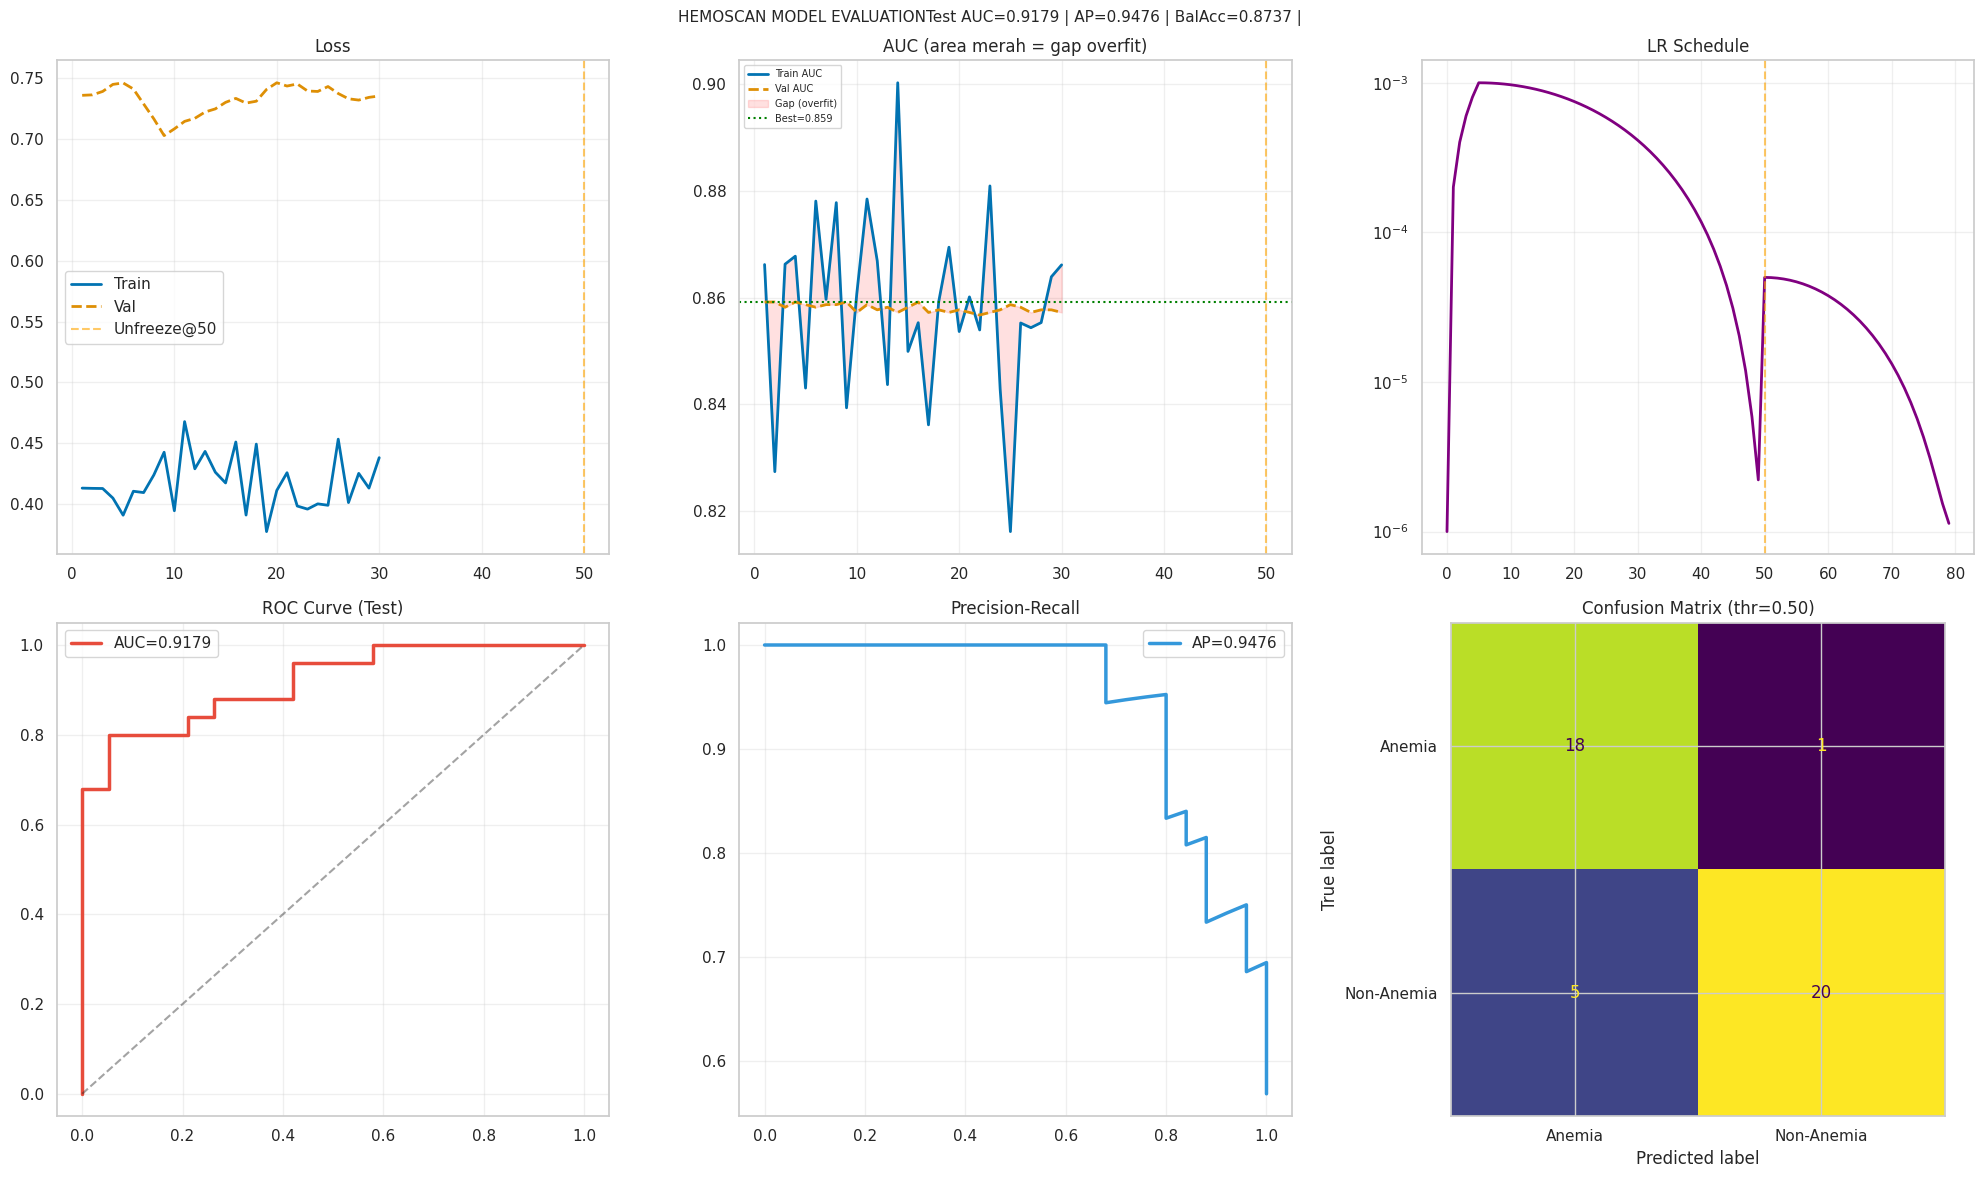

In [18]:

# ================================================================
# CELL 15 — VISUALISASI
# ================================================================

ep     = list(range(1, len(history2.history['loss']) + 1))
ep_all = list(range(TOTAL_EPOCHS))
lrs    = [cosine_warmup_lr(e) for e in ep_all]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

best_val_auc = max(history2.history['val_auc'])

# Loss
ax = axes[0,0]
ax.plot(ep, history2.history['loss'],     label='Train', lw=2)
ax.plot(ep, history2.history['val_loss'], label='Val',   lw=2, ls='--')
ax.axvline(UNFREEZE_EPOCH, color='orange', ls='--', alpha=0.6,
           label=f'Unfreeze@{UNFREEZE_EPOCH}')
ax.set_title('Loss'); ax.legend(); ax.grid(alpha=0.3)

# AUC dengan overfit gap
ax = axes[0,1]
ax.plot(ep, history2.history['auc'],     label='Train AUC', lw=2)
ax.plot(ep, history2.history['val_auc'], label='Val AUC',   lw=2, ls='--')
ax.fill_between(ep,
    history2.history['auc'], history2.history['val_auc'],
    alpha=0.12, color='red', label='Gap (overfit)')
ax.axhline(best_val_auc, color='green', ls=':',
           label=f'Best={best_val_auc:.3f}')
ax.axvline(UNFREEZE_EPOCH, color='orange', ls='--', alpha=0.6)
ax.set_title('AUC (area merah = gap overfit)')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# LR Schedule
ax = axes[0,2]
ax.plot(ep_all, lrs, color='purple', lw=2)
ax.axvline(UNFREEZE_EPOCH, color='orange', ls='--', alpha=0.6)
ax.set_title('LR Schedule'); ax.set_yscale('log'); ax.grid(alpha=0.3)

# ROC Curve
ax = axes[1,0]
fpr, tpr, _ = roc_curve(y_test, proba_test)
ax.plot(fpr, tpr, lw=2.5, color='#e74c3c', label=f'AUC={test_auc:.4f}')
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_title('ROC Curve (Test)'); ax.legend(); ax.grid(alpha=0.3)

# Precision-Recall
ax = axes[1,1]
prec, rec, _ = precision_recall_curve(y_test, proba_test)
ax.plot(rec, prec, lw=2.5, color='#3498db', label=f'AP={ap_test:.4f}')
ax.set_title('Precision-Recall'); ax.legend(); ax.grid(alpha=0.3)

# Confusion Matrix
ax = axes[1,2]
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred),
    display_labels=le.classes_
).plot(ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix (thr={BEST_THRESH:.2f})')

plt.suptitle(
    f'HEMOSCAN MODEL EVALUATION'
    f'Test AUC={test_auc:.4f} | AP={ap_test:.4f} | BalAcc={bacc:.4f} | ',
    fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'evaluation.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [19]:
!pip install tf2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 23.6 MB/s eta 0:00:00


In [20]:
# ================================================================
# CELL 16 — SIMPAN MODEL (KERAS, PICKLE, & ONNX)
# ================================================================
import os
import joblib
import tf2onnx
import tensorflow as tf

# 1. Simpan Model Keras & Label Encoder Standar
model.save(os.path.join(OUTPUT_DIR, 'anemia_model_final.keras'))
joblib.dump(le, os.path.join(OUTPUT_DIR, 'label_encoder.pkl'))

# 2. Simpan Metadata & Konfigurasi Proyek
config_saved = {
    'img_size'        : IMG_SIZE,
    'best_thresh'     : BEST_THRESH,
    'n_tta'           : N_TTA,
    'anemia_idx'      : ANEM_IDX,
    'classes'         : list(le.classes_),
    'test_auc'        : float(test_auc),
    'test_ap'         : float(ap_test),
    'image_keyword'   : IMAGE_KEYWORD,
    'synth_multiplier': SYNTH_MULTIPLIER,
    'n_train'         : len(train_df),
    'n_val'           : len(val_df),
    'n_test'          : len(test_df),
}
joblib.dump(config_saved, os.path.join(OUTPUT_DIR, 'config.pkl'))

# ================================================================
# 🔥 PROSES KONVERSI KE ONNX
# ================================================================
print("🔄 Memulai konversi model ke format ONNX...")

# Tentukan spesifikasi input (menyesuaikan IMG_SIZE dan channel RGB)
# Menggunakan [None, ...] agar batch size tetap dinamis saat deploy nanti
input_signature = [tf.TensorSpec([None, IMG_SIZE, IMG_SIZE, 3], tf.float32, name="input_layer")]

onnx_path = os.path.join(OUTPUT_DIR, 'anemia_model_final.onnx')

# Proses convert menggunakan tf2onnx
model_proto, _ = tf2onnx.convert.from_keras(
    model, 
    input_signature=input_signature, 
    output_path=onnx_path
)

print(f'✅ Model Keras & Config tersimpan.')
print(f'🚀 Model ONNX sukses diekspor ke: {onnx_path}')

🔄 Memulai konversi model ke format ONNX...


I0000 00:00:1780389731.847298      23 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1780389731.847522      23 single_machine.cc:374] Starting new session
I0000 00:00:1780389731.861016      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780389731.862501      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1780389733.671768      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780389733.673302      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 M

✅ Model Keras & Config tersimpan.
🚀 Model ONNX sukses diekspor ke: /kaggle/working/model_anemia/anemia_model_final.onnx


In [21]:
# ================================================================
# CELL 17 — FUNGSI INFERENCE
# ================================================================

def prediksi_anemia(image_path, model, config_dict):
    """
    Prediksi anemia dari satu gambar palpebral.
    Menggunakan TTA untuk prediksi lebih stabil.
    """
    thresh  = config_dict['best_thresh']
    n_tta_i = config_dict['n_tta']

    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return {'error': f'Gambar tidak bisa dibaca: {image_path}'}

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    probas  = []
    for i in range(n_tta_i):
        aug     = aug_eval if i == 0 else aug_tta
        arr     = preprocess_input(
                      aug(image=img_rgb)['image'].astype(np.float32))
        probas.append(
            float(model.predict(arr[np.newaxis], verbose=0)[0, 0]))

    proba     = float(np.mean(probas))
    is_anemia = proba >= thresh
    return {
        'prediksi'    : 'Anemia' if is_anemia else 'Non-Anemia',
        'probabilitas': round(proba, 4),
        'confidence'  : round(proba if is_anemia else 1 - proba, 4),
        'threshold'   : round(thresh, 2),
        'keterangan'  : ('⚠️  Kemungkinan anemia — konsultasi dokter.'
                         if is_anemia
                         else '✅ Tidak terindikasi anemia.'),
    }


# Contoh prediksi
sample_path = test_df['full_path'].iloc[0]
if os.path.exists(sample_path):
    hasil = prediksi_anemia(sample_path, model, config_saved)
    print('\nContoh prediksi:')
    for k, v in hasil.items():
        print(f'  {k:15s}: {v}')
    print(f'  {"label asli":15s}: {test_df["label"].iloc[0]}')

print('\n' + '='*60)
print('✅ SELESAI')
print('='*60)


Contoh prediksi:
  prediksi       : Anemia
  probabilitas   : 0.9822
  confidence     : 0.9822
  threshold      : 0.5
  keterangan     : ⚠️  Kemungkinan anemia — konsultasi dokter.
  label asli     : Non-Anemia

✅ SELESAI
